# CMIP6 Case A — Step 5b: Land-ice relationship stress test

## English overview

This notebook runs after Step 5 because it uses the completed Köppen four-zone table as the core reference. The four-zone core analysis intentionally uses non-ice land because its target is ordinary terrestrial precipitation partitioning. This auxiliary notebook does **not** merge permanent land ice into the Cold–Dry (CD) region. Instead, it treats land ice as a separate `LI` cryospheric regime and asks whether the proposed tree can recognize a fundamentally different or degenerate relationship structure.

For ordinary land, the long-term approximation is $P \approx ET + R$. Over permanent land ice, the relevant balance is closer to $P = E_{\mathrm{sublimation}} + R + \Delta S_{\mathrm{ice}}$. Therefore, $P-ET-R$ is reported as an **apparent residual**, not interpreted as a measured ice-storage tendency.

## 中文说明

本notebook放在Step 5之后，因为它以已经完成的Köppen四区表作为核心参照。四区主分析继续只使用无冰陆地，因为它研究的是普通陆地降水在蒸散和径流之间的分配。本notebook不把永久冰盖并入冷干区（CD），而是建立独立的 `LI` 冰冻圈组，作为decision tree的负对照和压力测试。

冰盖上的 `evspsbl` 主要反映升华、凝结或沉积，`mrro` 也可能由模型边界条件或冰面处理方式决定，因此冰盖关系不能与WW、WD、CW、CD作相同的水文解释。

## Step 0 — Configuration and imports / 配置与导入

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 240,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#30343B", "axes.linewidth": 0.9,
})

START_YEAR = 1985
END_YEAR = 2014
RATIO_MIN_P_MM_YR = 1.0
WRITE_OUTPUTS = True

def find_case_dir(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "P").exists() and (candidate / "derived").exists():
            return candidate
        nested = candidate / "case" / "caseA"
        if (nested / "P").exists() and (nested / "derived").exists():
            return nested
    raise FileNotFoundError("Could not locate case/caseA.")

CASE_DIR = find_case_dir()
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step5b"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Case directory: {CASE_DIR}")

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA


## Step 1 — Load matching CMIP6 fields and define land ice / 读取匹配数据并定义永久冰盖

All fields must come from MPI-ESM1-2-LR historical `r1i1p1f1` on the native `gn` grid. `sftgif` is the percentage of a grid cell covered by an ice sheet, ice shelf, ice cap, or glacier. The `LI` mask requires both land and positive permanent land-ice cover.

所有变量必须来自相同模型、试验、variant和原生网格。`LI`要求网格同时属于陆地且具有永久陆地冰覆盖。

In [2]:
FILES = {
    "P": CASE_DIR / "P" / "pr_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_18500116-20141216.nc",
    "ET": CASE_DIR / "ET" / "evspsbl_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_18500116-20141216.nc",
    "R": CASE_DIR / "Runoff" / "mrro_Lmon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_18500116-20141216.nc",
    "area": CASE_DIR / "areacella" / "areacella_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc",
    "land": CASE_DIR / "sftlf" / "sftlf_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc",
    "ice": CASE_DIR / "sftgif_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc",
}
for path in FILES.values():
    if not path.exists():
        raise FileNotFoundError(path)

datasets = {key: xr.open_dataset(path) for key, path in FILES.items()}
variables = {"P": "pr", "ET": "evspsbl", "R": "mrro", "area": "areacella", "land": "sftlf", "ice": "sftgif"}

def normalize_longitude(da):
    return da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

sftlf = normalize_longitude(datasets["land"][variables["land"]])
sftgif = normalize_longitude(datasets["ice"][variables["ice"]])
areacella = normalize_longitude(datasets["area"][variables["area"]])
ref_lat, ref_lon = sftlf.lat, sftlf.lon

def harmonize(da, name):
    da = normalize_longitude(da)
    if da.sizes.get("lat") != ref_lat.size or da.sizes.get("lon") != ref_lon.size:
        raise ValueError(f"{name}: horizontal shape mismatch")
    if not np.allclose(da.lat, ref_lat, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: latitude mismatch")
    if not np.allclose(da.lon, ref_lon, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: longitude mismatch")
    return da.assign_coords(lat=ref_lat, lon=ref_lon)

P_flux = harmonize(datasets["P"][variables["P"]], "P")
ET_flux = harmonize(datasets["ET"][variables["ET"]], "ET")
R_flux = harmonize(datasets["R"][variables["R"]], "R")
areacella = harmonize(areacella, "areacella")
sftgif = harmonize(sftgif, "sftgif")

land_mask = sftlf > 0
land_ice_mask = land_mask & (sftgif > 0)
non_ice_mask = land_mask & ~(sftgif > 0)
ice_area = (areacella * sftgif / 100).where(land_ice_mask, 0).rename("ice_area")

mask_audit = pd.Series({
    "land_cells": int(land_mask.sum()),
    "non_ice_land_cells": int(non_ice_mask.sum()),
    "land_ice_cells": int(land_ice_mask.sum()),
    "minimum_positive_sftgif_percent": float(sftgif.where(sftgif > 0).min()),
    "maximum_sftgif_percent": float(sftgif.max()),
    "land_ice_area_million_km2": float(ice_area.sum() / 1e12),
})
display(mask_audit.to_frame("value"))

,value
land_cells,6222.000000
non_ice_land_cells,4172.000000
land_ice_cells,2050.000000
minimum_positive_sftgif_percent,100.000000
maximum_sftgif_percent,100.000000
land_ice_area_million_km2,15.767745


## Step 2 — Convert monthly fluxes and construct LI climatology / 转换月通量并构建冰盖气候态

Monthly mean fluxes are integrated using their exact time bounds to obtain annual totals in $\mathrm{mm\,yr^{-1}}$. Fractions are ratios of 30-year mean fluxes, not means of annual ratios.

月平均通量使用精确时间边界积分为年总量。长期比例采用30年平均通量之比。

In [3]:
def annual_totals_from_flux(da, ds):
    selected = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))
    bounds = ds["time_bnds"].sel(time=selected.time)
    seconds = (bounds.isel(bnds=1) - bounds.isel(bnds=0)) / np.timedelta64(1, "s")
    if selected.sizes["time"] != (END_YEAR - START_YEAR + 1) * 12:
        raise ValueError("Selected period does not contain exactly 360 months")
    if not np.all(selected.time.groupby("time.year").count().values == 12):
        raise ValueError("At least one year does not contain 12 months")
    return (selected * seconds).groupby("time.year").sum("time", skipna=False).astype("float32")

P_annual = annual_totals_from_flux(P_flux, datasets["P"]).rename("P")
ET_annual = annual_totals_from_flux(ET_flux, datasets["ET"]).rename("ET")
R_annual = annual_totals_from_flux(R_flux, datasets["R"]).rename("R")
WB_annual = (P_annual - ET_annual - R_annual).rename("apparent_WB")

P = P_annual.mean("year").where(land_ice_mask).rename("P")
ET = ET_annual.mean("year").where(land_ice_mask).rename("ET")
R = R_annual.mean("year").where(land_ice_mask).rename("R")
apparent_WB = (P - ET - R).rename("apparent_WB")
valid_ratio = P > RATIO_MIN_P_MM_YR
ET_fraction = xr.where(valid_ratio, ET / P, np.nan).rename("ET_fraction_climatology")
R_fraction = xr.where(valid_ratio, R / P, np.nan).rename("R_fraction_climatology")
WB_fraction = xr.where(valid_ratio, apparent_WB / P, np.nan).rename("apparent_WB_fraction")
complete_case = (P.notnull() & ET.notnull() & R.notnull()).rename("complete_case")

ice_ds = xr.Dataset({
    "P": P, "ET": ET, "R": R, "apparent_WB": apparent_WB,
    "ET_fraction_climatology": ET_fraction,
    "R_fraction_climatology": R_fraction,
    "apparent_WB_fraction": WB_fraction,
    "complete_case": complete_case.astype("int8"),
    "land_fraction": sftlf.astype("float32"),
    "land_ice_fraction": sftgif.astype("float32"),
    "cell_area": areacella.astype("float32"),
    "analysis_area": ice_area.astype("float32"),
}).where(land_ice_mask)
ice_ds.attrs.update({
    "title": "MPI-ESM1-2-LR land-ice relationship stress-test climatology",
    "analysis_period": f"{START_YEAR}-{END_YEAR}",
    "regime": "LI (Land Ice)",
    "interpretation": "Cryospheric negative control; apparent_WB is not an observed ice-storage tendency",
})

ice_table_all = ice_ds.to_dataframe().reset_index()
ice_table_all = ice_table_all.loc[ice_table_all["land_ice_fraction"] > 0].copy()
ice_table = ice_table_all.loc[ice_table_all["complete_case"] == 1].copy().reset_index(drop=True)
ice_table["grid_id"] = [f"MPI_LI_{i:06d}" for i in range(1, len(ice_table) + 1)]
ice_table["zone"] = "LI"
ice_table["zone_label"] = "Land Ice"
ice_table["regime_family"] = "Cryospheric"
ice_table["analysis_scope"] = "Stress test only"
ice_table["negative_ET"] = ice_table["ET"] < 0
ice_table["zero_R"] = ice_table["R"] == 0
ice_table["large_apparent_WB"] = ice_table["apparent_WB"].abs() > 10

coverage = pd.Series({
    "LI_mask_cells": len(ice_table_all),
    "LI_complete_P_ET_R_cells": len(ice_table),
    "LI_incomplete_cells": len(ice_table_all) - len(ice_table),
    "negative_ET_share": float(ice_table["negative_ET"].mean()),
    "zero_R_share": float(ice_table["zero_R"].mean()),
    "R_variance": float(ice_table["R"].var()),
    "median_apparent_WB_over_P": float(ice_table["apparent_WB_fraction"].median()),
})
display(coverage.to_frame("value"))
display(ice_table[["P", "ET", "R", "apparent_WB", "ET_fraction_climatology", "R_fraction_climatology", "apparent_WB_fraction"]].describe().T)

,value
LI_mask_cells,2050.000000
LI_complete_P_ET_R_cells,2050.000000
LI_incomplete_cells,0.000000
negative_ET_share,0.732195
zero_R_share,1.000000
R_variance,0.000000
median_apparent_WB_over_P,1.031908


,count,mean,std,min,25%,50%,75%,max
P,2050.0,161.565277,180.304565,12.234845,51.041180,94.105480,205.061760,1836.059814
ET,2050.0,0.621630,13.088116,-119.450783,-3.479353,-2.285526,0.465393,110.207977
R,2050.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
apparent_WB,2050.0,160.943665,175.328934,14.459594,54.178238,98.281914,203.817886,1804.061523
ET_fraction_climatology,2050.0,-0.029614,0.063583,-0.313499,-0.069809,-0.031908,0.004014,0.339152
R_fraction_climatology,2050.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
apparent_WB_fraction,2050.0,1.029614,0.063583,0.660848,0.995986,1.031908,1.069809,1.313499


## Step 3 — Diagnose whether LI is a relationship case or a negative control / 判断LI是关系案例还是负对照

A tree requires variation in the response. If runoff or runoff fraction is constant over LI cells, the corresponding pair is a valid **no-relationship negative control**, but it is not evidence for a non-trivial runoff-partitioning curve.

如果冰盖上的径流或径流比例没有变化，那么该配对只能用于测试tree是否正确识别无关系，不能作为复杂径流分配曲线。

,pair,x_sd,y_sd,status,tree_input_has_response_variation
0,P -> ET,180.304565,13.088116,Descriptive cryospheric relationship,True
1,P -> R,180.304565,0.000000,Negative control if runoff is constant,False
2,P -> R/P,180.304565,0.000000,Negative control if runoff fraction is constant,False


/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_24560/1816002607.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(figure_path, bbox_inches="tight")


/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


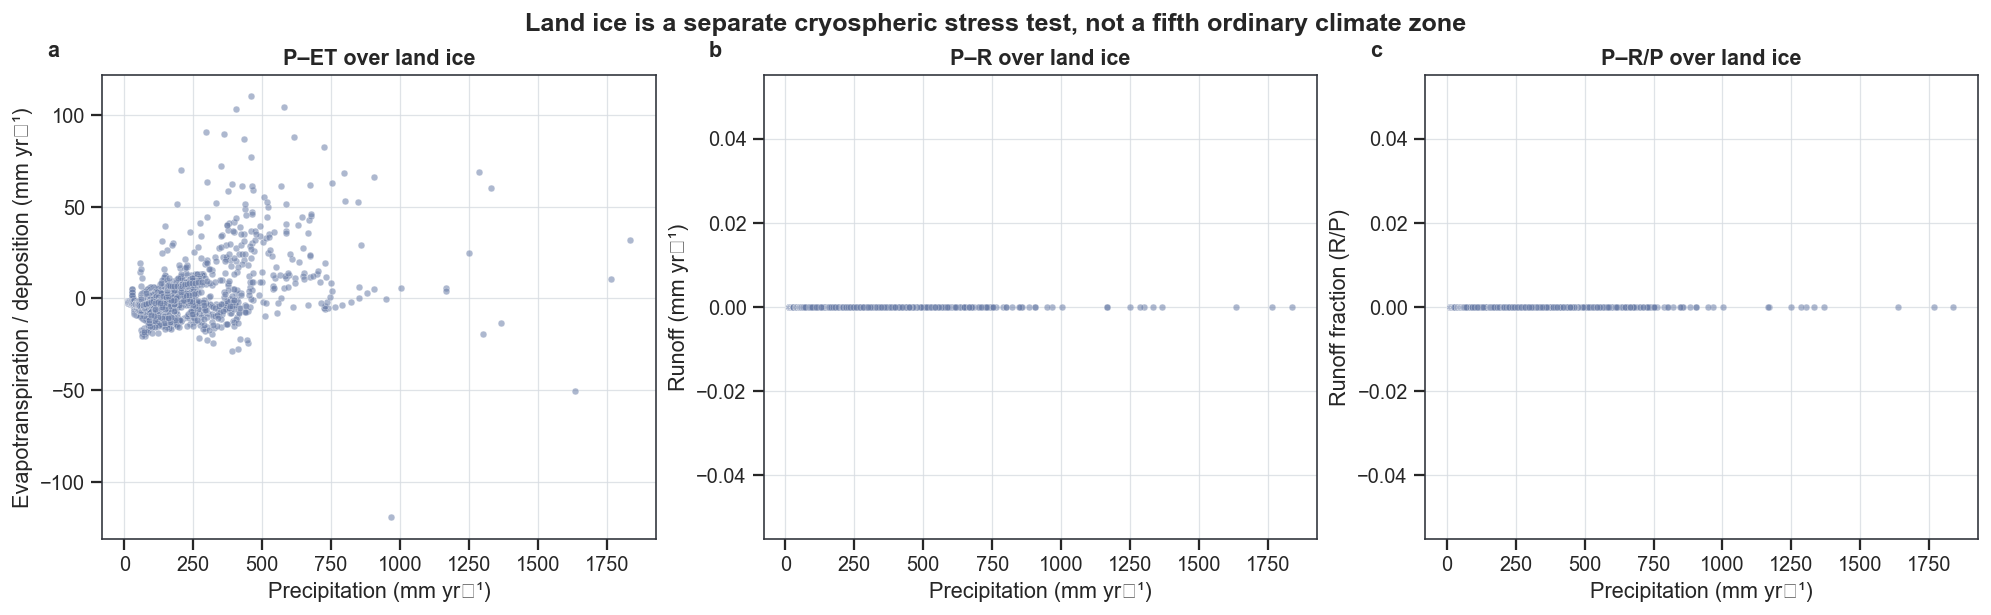

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step5b/land_ice_relationship_stress_test.png


In [4]:
relationship_audit = pd.DataFrame([
    {"pair": "P -> ET", "x_sd": ice_table["P"].std(), "y_sd": ice_table["ET"].std(),
     "status": "Descriptive cryospheric relationship"},
    {"pair": "P -> R", "x_sd": ice_table["P"].std(), "y_sd": ice_table["R"].std(),
     "status": "Negative control if runoff is constant"},
    {"pair": "P -> R/P", "x_sd": ice_table["P"].std(), "y_sd": ice_table["R_fraction_climatology"].std(),
     "status": "Negative control if runoff fraction is constant"},
])
relationship_audit["tree_input_has_response_variation"] = relationship_audit["y_sd"] > 0
display(relationship_audit)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.4), constrained_layout=True)
specs = [
    ("P", "ET", "P–ET over land ice", "Evapotranspiration / deposition (mm yr⁻¹)"),
    ("P", "R", "P–R over land ice", "Runoff (mm yr⁻¹)"),
    ("P", "R_fraction_climatology", "P–R/P over land ice", "Runoff fraction (R/P)"),
]
for panel, (ax, (x, y, title, ylabel)) in enumerate(zip(axes, specs)):
    ax.scatter(ice_table[x], ice_table[y], s=14, alpha=0.55, color="#6B7EA8",
               edgecolors="white", linewidths=0.25, rasterized=True)
    ax.set_title(title, fontweight="semibold")
    ax.set_xlabel("Precipitation (mm yr⁻¹)")
    ax.set_ylabel(ylabel)
    ax.grid(True, color="#D7DCE2", linewidth=0.7, alpha=0.8)
    ax.text(-0.10, 1.04, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
fig.suptitle("Land ice is a separate cryospheric stress test, not a fifth ordinary climate zone", y=1.04, fontsize=14, fontweight="bold")
figure_path = FIGURE_DIR / "land_ice_relationship_stress_test.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")

## Step 4 — Save a separate LI table and an explicitly labelled combined table / 保存独立LI表和明确标记的合并表

The combined product is provided for method stress testing only. `LI` must remain identifiable through `regime_family` and `analysis_scope`; it must not be pooled with CD or interpreted as ordinary land partitioning.

合并表仅服务于方法压力测试。LI必须始终通过`regime_family`和`analysis_scope`与普通陆地区分，不能与CD合并解释。

In [5]:
CORE_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zone_climatology_1985_2014.parquet"
if not CORE_TABLE.exists():
    raise FileNotFoundError(CORE_TABLE)
core = pd.read_parquet(CORE_TABLE).copy()
core["zone"] = core["zone"].astype(str)
core["zone_label"] = core["zone"].map({"WW": "Warm–Wet", "WD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"})
core["regime_family"] = "Non-ice terrestrial"
core["analysis_scope"] = "Core analysis"
core["analysis_area"] = core["land_area"]
core["apparent_WB"] = core["WB"]
core["apparent_WB_fraction"] = core["WB_fraction_climatology"]

columns = [
    "lat", "lon", "grid_id", "zone", "zone_label", "regime_family", "analysis_scope",
    "P", "ET", "R", "apparent_WB", "ET_fraction_climatology",
    "R_fraction_climatology", "apparent_WB_fraction", "analysis_area",
    "land_fraction", "land_ice_fraction", "negative_ET", "zero_R",
]
combined = pd.concat([core[columns], ice_table[columns]], ignore_index=True, sort=False)
combined["zone"] = pd.Categorical(combined["zone"], categories=["WW", "WD", "CW", "CD", "LI"], ordered=True)

ICE_TABLE = DERIVED_DIR / f"MPI_ESM1_2_LR_land_ice_stress_test_{START_YEAR}_{END_YEAR}.parquet"
COMBINED_TABLE = DERIVED_DIR / f"MPI_ESM1_2_LR_core_plus_land_ice_stress_test_{START_YEAR}_{END_YEAR}.parquet"
AUDIT_CSV = DERIVED_DIR / f"MPI_ESM1_2_LR_land_ice_relationship_audit_{START_YEAR}_{END_YEAR}.csv"
ICE_NETCDF = DERIVED_DIR / f"MPI_ESM1_2_LR_land_ice_climatology_{START_YEAR}_{END_YEAR}.nc"

if WRITE_OUTPUTS:
    ice_table.to_parquet(ICE_TABLE, index=False, compression="zstd")
    combined.to_parquet(COMBINED_TABLE, index=False, compression="zstd")
    relationship_audit.to_csv(AUDIT_CSV, index=False)
    encoding = {name: {"zlib": True, "complevel": 4} for name in ice_ds.data_vars}
    ice_ds.to_netcdf(ICE_NETCDF, encoding=encoding)

manifest = pd.DataFrame([
    {"product": "LI complete-case table", "path": str(ICE_TABLE), "rows": len(ice_table)},
    {"product": "Core + LI stress-test table", "path": str(COMBINED_TABLE), "rows": len(combined)},
    {"product": "LI relationship audit", "path": str(AUDIT_CSV), "rows": len(relationship_audit)},
    {"product": "LI gridded climatology", "path": str(ICE_NETCDF), "rows": int(land_ice_mask.sum())},
])
display(manifest)
display(combined.groupby(["regime_family", "zone"], observed=True).size().rename("grid_cells").to_frame())

,product,path,rows
0,LI complete-case table,/Users/mimi/Documents/Code/Github/GSA-work/exp...,2050
1,Core + LI stress-test table,/Users/mimi/Documents/Code/Github/GSA-work/exp...,6222
2,LI relationship audit,/Users/mimi/Documents/Code/Github/GSA-work/exp...,3
3,LI gridded climatology,/Users/mimi/Documents/Code/Github/GSA-work/exp...,2050


grid_cells
regime_family       zone            
Cryospheric         LI          2050
Non-ice terrestrial WW           662
                    WD          1243
                    CW          1491
                    CD           776

## Step 5 — Interpretation and routing decision / 解释与tree路由决定

- WW, WD, CW, and CD remain the scientifically comparable core analysis.
- LI is an auxiliary cryospheric stress test and must never be relabelled as CD.
- If `R` and `R/P` have zero variance in LI, `P -> R` and `P -> R/P` should be routed as negative-control cases rather than fitted as non-trivial curves.
- Negative `evspsbl` over LI is retained and flagged because it may represent net deposition/condensation; it is not ordinary vegetated-land ET.
- The apparent residual $P-ET-R$ is diagnostic only. A physical ice-sheet budget would require a compatible ice-storage tendency and careful checking of model conventions.

### 中文结论

- WW、WD、CW、CD继续构成可比较的普通陆地核心分析。
- LI只作为冰冻圈压力测试，不能重新标记为CD。
- 如果LI中的R和R/P方差为零，则相应配对应作为无关系负对照，而不是拟合复杂曲线。
- 冰盖上的负`evspsbl`保留并标记，因为它可能代表凝结或沉积，而非植被陆地蒸散。
- $P-ET-R$只作为表观残差。要建立真正的冰盖水量平衡，还需要兼容的冰储量变化数据和变量定义检查。